# TP21 - Dijkstra : 25 bosses

!!! info Contexte
À la fin de l'année scolaire les étudiant.e.s de MPSI et PCSI ont décidé.e.s de faire la randonnée des 25 bosses avec leurs professeurs. Cependant, arriver à la bosse numéro 4, un professeur s'est foulé la cheville. Il arrive à marcher à plat mais le dénivelé (positif ou négatif) lui fait mal à la cheville. Vous vous mettez donc à chercher le trajet vers le parking qui nécessite le moins de dénivelé pour ramener votre professeur dans le meilleur état possible.
!!!

!!! example Modélisation 
On modélise les bosses et le parking par des sommets et les chemins de randonnées par des arrêtes pondérées. Chaque arrête possède donc un poids correspondant au total de dénivelé (+ et -) entre 2 sommets.
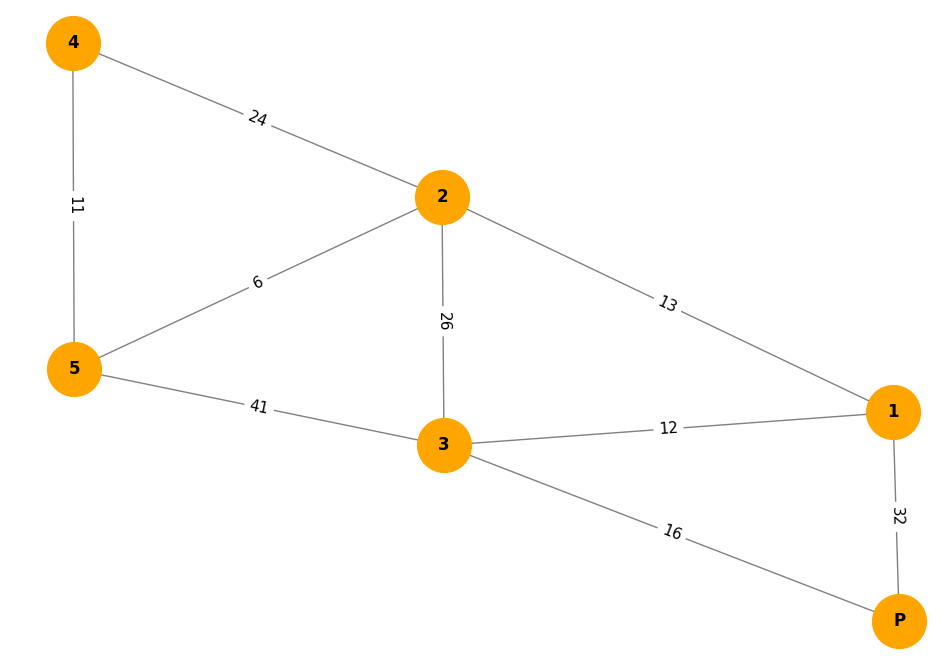
!!!

!!! question Question 1
Compléter le dictionnaire `bosses` représentant le graphe précédant. 
!!!

In [1]:
bosses = {
    "P": [("1", 32), ("3", 16)],
    "1": [("P", 32), ("3", 12), ("2", 13)],
    "2": [("1", 13), ("3", 26), ("4", 24), ("5", 6)], 
    # ...
}

In [2]:
bosses = {
    "P": [("1", 32), ("3", 16)],
    "1": [("P", 32), ("3", 12), ("2", 13)],
    "2": [("1", 13), ("3", 26), ("4", 24), ("5", 6)], 
    "3": [("P", 16), ("1", 12), ("2", 26), ("5", 41)],
    "4": [("2", 24), ("5", 11)], 
    "5": [("2", 6) , ("3", 41), ("4", 11)]
}

!!! info infini 
Pour initialiser l'infini on dispose de 2 méthodes différentes : 
```python
import math
x = math.inf

# ou 

x = float("inf")
```
!!!

In [3]:
import math
x = math.inf
y = float("inf")
print(x)
print(y)
print(x==y)

inf
inf
True


!!! question Question 2
Écrire une fonction `min_s_a_visiter(distances: dict, a_visiter: ens) -> str`
- Entrée :
    - `distance` : un dictionnaire où les clés sont les sommets du graphe et les valeurs les plus courtes distance trouvé pour le moment d'un sommet source vers ce sommet
    - `a_visiter` : un ensemble contenant des sommets (qui sont des clés dans distance)
- Sortie : 
    - nom du sommet dans `a_visiter` avec la distance la plus petite
!!!

In [20]:
def min_s_a_visiter(distances, a_visiter):
    s_max = None
    for s in a_visiter:
        if s_max is None or distances[s] < distances[s_max]:
            s_max = s
    return s_max

In [21]:
print(min_s_a_visiter({'P': math.inf, '1': math.inf, '2': math.inf, '3': math.inf, '4': 0, '5': math.inf}, 
                      {'P', '1', '2', '3', '4', '5'})) #4

4


!!! question Question 3
Écrire une fonction `dijkstra(g: dict, src: str) -> dict[str:int]` qui prend en paramètre un graphe et un sommet source et renvoie un dictionnaire contenant les distances minimales (ici cumul de dénivelé minimal) de la source vers tous les autres sommets du graphe.
!!!

!!! example Algorithme
<style>
    .aide-dfs-container { margin: 20px 0; }
    .aide-dfs-details { border: 2px dashed #007bff; border-radius: 8px; background-color: #f0f7ff; }
    .aide-dfs-summary { padding: 10px; font-weight: bold; color: #0056b3; cursor: pointer; list-style: none; text-align: center; }
    .aide-dfs-summary:before { content: "⚙️ "; }
    .aide-dfs-content { padding: 15px; border-top: 1px solid #bbdefb; color: #333; line-height: 1.6; }
    .code-logic { font-family: 'Courier New', Courier, monospace; font-weight: bold; color: #d81b60; }
    .indent { padding-left: 20px; border-left: 1px solid #ccc; }
    .comment { color: #6a9955; font-style: italic; font-weight: normal; }
</style>

<div class="aide-dfs-container">
<details class="aide-dfs-details">
<summary class="aide-dfs-summary">Voir pour aide : Dijkstra</summary>
<div class="aide-dfs-content">

<span class="code-logic">dijkstra(g, src) :</span>
<div class="indent">
    <b>Pour chaque</b> sommet <span class="code-logic">v</span> du graphe :
    <div class="indent">  
        <span class="code-logic">distances[v] = +∞</span>
    </div>
    <span class="code-logic">distances[src] = 0</span><br>
    <span class="code-logic">a_visiter</span> = ensemble de tous les sommets<br>
    <b>Tant que</b> <span class="code-logic">a_visiter</span> n'est pas vide :
    <div class="indent">
        <span class="code-logic">u</span> = sommet de <span class="code-logic">a_visiter</span> avec <span class="code-logic">distances[u]</span> minimale<br>
        Retirer <span class="code-logic">u</span> de <span class="code-logic">a_visiter</span><br>
        <b>Pour chaque</b> successeur <span class="code-logic">v</span> de <span class="code-logic">u</span> :
        <div class="indent">
            <b>Si</b> <span class="code-logic">v</span> est dans <span class="code-logic">a_visiter</span> :
            <div class="indent">
                <span class="code-logic">alt</span> = <span class="code-logic">distances[u]</span> + poids de l'arc <span class="code-logic">u → v</span><br>
                <b>Si</b> <span class="code-logic">alt</span> inférieur <span class="code-logic">distances[v]</span> :
                <div class="indent">
                    <span class="code-logic">distances[v] = alt</span> <span class="comment">// On a trouvé un meilleur chemin</span>
                </div>
            </div>
        </div>
    </div>
    <b>Retourner</b> <span class="code-logic">distances</span>
</div>

</div>
</details>
</div>
!!!

In [22]:
def dijkstra(g, src):
    distances = {s : math.inf for s in g}
    distances[src] = 0
    a_visiter = {s for s in g}
    while len(a_visiter) != 0:
        u = min_s_a_visiter(distances, a_visiter)
        a_visiter.remove(u)
        for v, poids_u_v in g[u]:
            if v in a_visiter :
                alt = distances[u] + poids_u_v
                if alt < distances[v]:
                    distances[v] = alt
    return distances

In [23]:
print(dijkstra(bosses, "4"))

{'P': 58, '1': 30, '2': 17, '3': 42, '4': 0, '5': 11}


!!! question Question 4
Donnez la complexité de votre fonction de l'algorithme de Dijkstra. 
!!!

!!! info File de priorité
Une file de priorité est une structure de donnée (on ne va pas l'implémenter) qui permet d'avoir un ensemble de n éléments et d'extraire le minimum (ou max) en O(log(n)), on aura aussi un O(log(n)) pour un ajout d'élément.

En Python, on utilise le module standard `heapq`.
!!!

In [24]:
import heapq

# 1. Créer une liste vide qui servira de file
file_priorite = []

# 2. Ajouter des éléments avec heapq.heappush(liste, element)
# ASTUCE : On met la priorité (la distance) en premier dans le tuple 
# si on compare 2 tuples on va comparer d'abord les 1er éléments puis les second...
heapq.heappush(file_priorite, (32, "Sommet_1"))
heapq.heappush(file_priorite, (12, "Sommet_3"))
heapq.heappush(file_priorite, (25, "Sommet_2"))

# 3. Extraire l'élément avec la plus petite priorité
# heapq.heappop retire et renvoie le plus petit tuple
distances, sommet = heapq.heappop(file_priorite)

print(f"Le plus proche est {sommet} à une distance de {distances}")
print(f"La file de priorité contient maintenant : {file_priorite}\n")
distance, sommet = heapq.heappop(file_priorite)
print(f"Le plus proche est {sommet} à une distance de {distances}")
print(f"La file de priorité contient maintenant : {file_priorite}")

Le plus proche est Sommet_3 à une distance de 12
La file de priorité contient maintenant : [(25, 'Sommet_2'), (32, 'Sommet_1')]

Le plus proche est Sommet_2 à une distance de 12
La file de priorité contient maintenant : [(32, 'Sommet_1')]


!!! question Question 5
Modifier votre fonction `dijkstra` pour qu'elle utilise une file de priorité plutôt que votre fonction `min_s_a_visiter`.
On va donc utiliser la file de priorité de la même façon dont on utilisait la `file` dans l'algorithme de parcours en largeur.

Grâce à la file de priorité nous aurons un algorithme en $O((|S|+|A|)log(|S|))$
<style>
    .aide-priority-container { margin: 20px 0; }
    .aide-priority-details { border: 2px dashed #28a745; border-radius: 8px; background-color: #f8fff9; }
    .aide-priority-summary { padding: 10px; font-weight: bold; color: #1e7e34; cursor: pointer; list-style: none; text-align: center; }
    .aide-priority-summary:before { content: "🚀 "; }
    .aide-priority-content { padding: 15px; border-top: 1px solid #c3e6cb; color: #333; line-height: 1.6; }
    .code-logic { font-family: 'Courier New', Courier, monospace; font-weight: bold; color: #d81b60; }
    .indent { margin-left: 20px; border-left: 1px solid #ccc; padding-left: 10px; }
    .comment { color: #6a9955; font-style: italic; font-weight: normal; }
</style>

<div class="aide-priority-container">
<details class="aide-priority-details">
<summary class="aide-priority-summary">Aide : Dijkstra avec File de Priorité (heapq)</summary>
<div class="aide-priority-content">

<span class="code-logic">dijkstra_optimise(g, src) :</span>
<div class="indent">
        <span class="code-logic">distances</span> = dictionnaire {sommet: +∞} pour chaque sommet de <span class="code-logic">g</span><br>
        <span class="code-logic">distances[src] = 0</span><br>
        <span class="code-logic">file_prio</span> = [ <span class="code-logic">(0, src)</span> ] <span class="comment">// Liste de tuples (distance, sommet)</span><br>
    <b>Tant que</b> <span class="code-logic">file_prio</span> n'est pas vide :
    <div class="indent">
        <span class="code-logic">(dist_u, u)</span> = Extraire le minimum de <span class="code-logic">file_prio</span><br>
        <b>Si</b> <span class="code-logic">dist_u > distances[u]</span> :<br>
        <div class="indent">
             <b>Passer</b> au tour suivant <span class="comment">// On a déjà trouvé mieux pour ce sommet</span>
        </div>
        <b>Pour chaque</b> successeur <span class="code-logic">v</span> de <span class="code-logic">u</span> :
        <div class="indent">
            <span class="code-logic">alt</span> = <span class="code-logic">distances[u]</span> + <span class="code-logic">poids_uv</span><br>
            <b>Si</b> <span class="code-logic">alt</span> < <span class="code-logic">distances[v]</span> :
            <div class="indent">
                <span class="code-logic">distances[v] = alt</span><br>
                Ajouter <span class="code-logic">(alt, v)</span> à la <span class="code-logic">file_prio</span>
            </div>
        </div>
    <b>Retourner</b> <span class="code-logic">distances</span>
</div>

</div>
</details>
</div>
!!!

In [25]:
def dijkstra(g, src):
    distances = {s : math.inf for s in g}
    distances[src] = 0
    file_prio = [(0, src)]
    while len(file_prio) != 0:
        dist_u, u = heapq.heappop(file_prio)
        if dist_u > distances[u]:
            continue
        for v, poids_u_v in g[u]:
            alt = distances[u] + poids_u_v
            if alt < distances[v]:
                distances[v] = alt
                heapq.heappush(file_prio, (alt, v))
    return distances

In [26]:
print(dijkstra(bosses, "4"))

{'P': 58, '1': 30, '2': 17, '3': 42, '4': 0, '5': 11}


!!! question Question 6
Maintenant qu'on a trouvé le nombre de dénivelé minimum pour rentrer au parking on souhaite trouver le chemin qu'il faut emprunter.

Reprennez votre fonction `dijkstra` en la modifiant pour retourner aussi un dictionnaire `parents` qui va pour chaque clé (sommet) associé la valeur du somment parent, celui depuis lequel nous somme arrivé pour avoir le plus court chemin. Le sommet de départ sera associé à la valeur `None`.

Par exemple, avec notre graphe, Dijkstra pourrait renvoyer le dictionnaire suivant :
```python
distances, parents = dijkstra(g, src)
print(parents) 
>> {'4': None, '2': '5', '5': '4', '3': '1', '1': '2', 'P': '3'}
# 4 est notre sommet de départ donc on n'a pas de parents pour ce sommet
# Pour le sommet 2 le plus court chemin est : 4 -> 5 -> 2 (la valeur associé à 2 est 5, celle de 5 est 4).
```
!!!

In [27]:
def dijkstra(g, src):
    distances = {s : math.inf for s in g}
    distances[src] = 0
    file_prio = [(0, src)]
    parents = {src: None}
    
    while len(file_prio) != 0:
        dist_u, u = heapq.heappop(file_prio)
        if dist_u > distances[u]:
            continue
        for v, poids_u_v in g[u]:
            alt = distances[u] + poids_u_v
            if alt < distances[v]:
                distances[v] = alt
                parents[v] = u
                heapq.heappush(file_prio, (alt, v))
    return distances, parents

In [33]:
print(dijkstra(bosses, "4"))
# ({'P': 58, '1': 30, '2': 17, '3': 42, '4': 0, '5': 11}, {'4': None, '2': '5', '5': '4', '3': '1', '1': '2', 'P': '3'})

({'P': 58, '1': 30, '2': 17, '3': 42, '4': 0, '5': 11}, {'4': None, '2': '5', '5': '4', '3': '1', '1': '2', 'P': '3'})


!!! question Question 7
Maintenant qu'on peut construire le dictionnaire des noeuds parents. Écrire une fonction `plus_court_chemin(g: dict, dest: str, src: str) -> list[str]` qui renvoie le plus court **chemin** entre 2 sommets. pour trouver le chemin que l'on doit emprunter pour ramener votre professeur au parking.
!!!

In [31]:
def plus_court_chemin(g, dest, src):
    dist, parents = dijkstra(g, src)
    chem = [dest]
    # tant qu'on est pas arrivé sur la source 
    while chem[-1] != src:
        # on remonte le chemin
        chem.append(parents[chem[-1]])
    return chem

In [34]:
print(plus_court_chemin(bosses, '4', 'P')) # ['4', '5', '2', '1', '3', 'P']

['4', '5', '2', '1', '3', 'P']


!!! question Question 6
Afficher votre graphe avec le chemin le plus court pour vérifier que celui-ci est le bon. \
_Executer les cellules suivantes_
!!!

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

def afficher_graphe_bosses_couleur(dico, chemin_a_surligner=None):
    # Initialisation du graphe
    G = nx.Graph()

    # Ajout des arêtes avec poids depuis ton format de tuples
    for u, voisins in dico.items():
        for v, poids in voisins:
            G.add_edge(u, v, weight=poids)

    # Positionnement des nœuds (fixe pour que les labels s'alignent)
    pos = nx.spring_layout(G, seed=42) 

    # --- Logique de coloration des arcs ---
    # Par défaut, toutes les arêtes sont grises
    couleurs_arcs = ['gray'] * G.number_of_edges()
    epaisseurs_arcs = [1] * G.number_of_edges()

    # Si un chemin est fourni, on identifie ses arêtes
    if chemin_a_surligner and len(chemin_a_surligner) > 1:
        # Création de la liste des paires d'arêtes du chemin : [(P,3), (3,1), (1,2)]
        aretes_chemin = []
        for i in range(len(chemin_a_surligner) - 1):
            u, v = chemin_a_surligner[i], chemin_a_surligner[i+1]
            aretes_chemin.append((u, v))
            aretes_chemin.append((v, u))

        # On parcourt toutes les arêtes du graphe pour colorer celles du chemin
        for i, (u, v) in enumerate(G.edges()):
            if (u, v) in aretes_chemin:
                couleurs_arcs[i] = 'red'    # Couleur du chemin minimal
                epaisseurs_arcs[i] = 3      # Plus épais pour mieux voir

    # --- Dessin ---
    plt.figure()

    # 1. Dessiner les nœuds
    nx.draw_networkx_nodes(G, pos, node_color='orange', node_size=1500)
    nx.draw_networkx_labels(G, pos, font_weight='bold')

    # 2. Dessiner les arêtes avec la liste de couleurs générée
    nx.draw_networkx_edges(G, pos, edge_color=couleurs_arcs, width=epaisseurs_arcs)

    # 3. Dessiner les étiquettes de poids
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=11)

    title = "Visualisation du parcours"
    if chemin_a_surligner:
        title += f" (Chemin minimal : {' → '.join(chemin_a_surligner)})"
    
    plt.title(title)
    plt.axis('off') # Cache les axes
    plt.show()


In [36]:
afficher_graphe_bosses_couleur(bosses, plus_court_chemin(bosses, '4', 'P'))